# Análisis de sentimiento en reseñas de cine en español: LSTM con atención vs. Transformers preentrenados

Taller 1 de Procesamiento de Lenguaje Natural.

Integrantes: Julián Espinosa, Jhon Jairo Cuervo, David Crespo.
Grupo Wiskey

## Qué hicimos distinto respecto a los notebooks guía

Los notebooks guía trabajan con clasificación temática de noticias en español (dataset `mteb/spanish_news`, 12 categorías). Para este taller decidimos cambiar de dominio y de tarea: usamos el dataset `us-lsi/muchocine` (cerca de 3.872 reseñas de películas escritas por usuarios reales de muchocine.net) para hacer clasificación de sentimiento (negativo, neutral, positivo), derivando la etiqueta de la calificación en estrellas que cada usuario le puso a la película.

Además del LSTM simple que aparece en el notebook guía, implementamos una segunda arquitectura clásica con BiLSTM y un mecanismo de atención propio, y una tercera basada en un Transformer preentrenado en español (BETO), para comparar los tres enfoques bajo las mismas métricas y el mismo conjunto de prueba. También construimos el vocabulario del tokenizador usando únicamente el conjunto de entrenamiento (los notebooks guía lo hacen con el dataset completo antes de separar los conjuntos, lo cual es una fuga leve de información), agregamos pesos de clase por el desbalance que encontramos en el análisis exploratorio, y sumamos un EDA completo, curvas de entrenamiento, matrices de confusión, visualización de los pesos de atención, un cruce de errores entre modelos y un demo con frases escritas por nosotros.


## 0. Preparación del entorno

In [ ]:
import warnings
warnings.filterwarnings('ignore')

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f'Ejecutando en Colab: {IN_COLAB}')

Ejecutando en Colab: True


In [ ]:
# transformers, datasets, evaluate y wordcloud no siempre vienen preinstalados en Colab.
# Usamos -U (upgrade) para 'datasets': Colab ya trae una versión preinstalada,
# y sin -U, pip la deja tal cual aunque sea vieja. Una versión vieja de
# 'datasets' combinada con el torch/torchvision más nuevo de Colab produce un
# ImportError interno (VideoReader) al convertir batches a tensores, aunque
# no estemos usando nada de video.
!test '{IN_COLAB}' = 'True' && pip install -q -U datasets transformers evaluate wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 16.1 MB/s eta 0:00:00


In [ ]:
import os
import re
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

sns.set_theme(style='whitegrid')

Dispositivo: cpu


## 1. Datos: reseñas de cine en español (Muchocine)

Usamos el dataset [`us-lsi/muchocine`](https://huggingface.co/datasets/us-lsi/muchocine): **3.872 reseñas de películas** escritas por usuarios reales del sitio muchocine.net, curadas por el Dr. Fermín L. Cruz Mata (Universidad de Sevilla). Cada registro trae:

- `review_body`: el texto completo de la reseña.
- `review_summary`: una versión resumida/título de la reseña.
- `star_rating`: la calificación en estrellas que el propio usuario le dio a la película, de 1 a 5.

Es un dataset completamente distinto al de los notebooks guía: otro dominio (opinión sobre cine vs. noticias), otra tarea (sentimiento vs. tema) y otra fuente.

In [ ]:
from datasets import load_dataset

# Nota: 'us-lsi/muchocine' es un dataset "antiguo" que trae un script de carga
# en Python (muchocine.py). Desde datasets>=4.0 esos scripts ya no se ejecutan
# por razones de seguridad, así que en vez de la rama principal cargamos la
# rama 'refs/convert/parquet', que Hugging Face genera automáticamente para
# todo dataset público con una copia en formato parquet (sin script).
# Si por alguna razón esto sigue fallando en tu entorno, la alternativa es
# fijar una versión antigua de la librería: pip install -q "datasets<4.0.0"
raw_dataset = load_dataset('us-lsi/muchocine', revision='refs/convert/parquet', split='train')
df = raw_dataset.to_pandas()
print(df.shape)
df.head()

default/train/0000.parquet: reconstructing file:   0%|          |  0.00B / 7.68MB            

default/train/0000.parquet: downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

(3872, 3)


,review_body,review_summary,star_rating
0,"""May, ¿Quieres ser mi amigo?"" es una de esas p...","May, ¿quieres ser mi amigo?",3
1,Es todo un alivio que ante tanta película que ...,Cómo ponerse en la piel de un kamikaze,3
2,"Una fiesta llena de excesos, rubias despampana...","Silicona, esteroides, pactos demoníacos y otra...",0
3,"Zoom nos cuenta la historia de Jack Shepard, a...",Una comedia entretenida y poca cosa más para v...,1
4,Luc Besson dirige esta película basada en sus ...,"Luc Besson sabe manejar la acción, y aquí lo d...",3


### 1.1 De estrellas a sentimiento

El dataset no trae una etiqueta de sentimiento directamente: la derivamos de `star_rating`. Usamos un mapeo simple de 3 clases:

- 1-2 estrellas → **negativo**
- 3 estrellas → **neutral**
- 4-5 estrellas → **positivo**

Esta es una decisión de diseño (podría hacerse binario descartando la clase 3, o mantenerse como regresión ordinal de 5 clases); la dejamos como 3 clases porque refleja mejor cómo se suele consumir este tipo de análisis en un producto real (¿es una reseña que requiere atención, es neutral, o es un elogio?).

In [ ]:
def rating_to_sentiment(rating: int) -> str:
    if rating <= 2:
        return 'negativo'
    elif rating == 3:
        return 'neutral'
    else:
        return 'positivo'

df['sentimiento'] = df['star_rating'].apply(rating_to_sentiment)
df['sentimiento'].value_counts()

,count
sentimiento,
negativo,2522
neutral,889
positivo,461


## 2. Análisis exploratorio de datos (EDA)

Antes de entrenar los modelos revisamos el dataset: qué tan balanceadas están las clases, qué tan largas son las reseñas, qué palabras predominan en cada clase y si hay datos sucios (nulos, duplicados, vacíos) que haya que limpiar.

In [ ]:
print('Valores nulos por columna:')
print(df.isnull().sum())
print()
print(f"Reseñas con texto exactamente duplicado: {df.duplicated(subset='review_body').sum()}")
print(f"Reseñas vacías o solo espacios: {(df['review_body'].str.strip() == '').sum()}")

Valores nulos por columna:
review_body       0
review_summary    0
star_rating       0
sentimiento       0
dtype: int64

Reseñas con texto exactamente duplicado: 3
Reseñas vacías o solo espacios: 1


In [ ]:
# Limpieza: quitamos reseñas sin contenido textual real (vacías, o que tras
# quitar signos de puntuación no dejan ninguna letra). No solo no aportan
# nada para entrenar: más adelante, una reseña con cero tokens válidos puede
# romper el mecanismo de atención (una fila de pesos totalmente en blanco).
def has_content(text):
    return bool(re.search(r'[a-záéíóúüñ]', text.lower()))

n_antes = len(df)
df = df[df['review_body'].apply(has_content)].reset_index(drop=True)
print(f'Reseñas eliminadas por no tener contenido textual: {n_antes - len(df)}')
print(f'Reseñas restantes: {len(df)}')

Reseñas eliminadas por no tener contenido textual: 1
Reseñas restantes: 3871


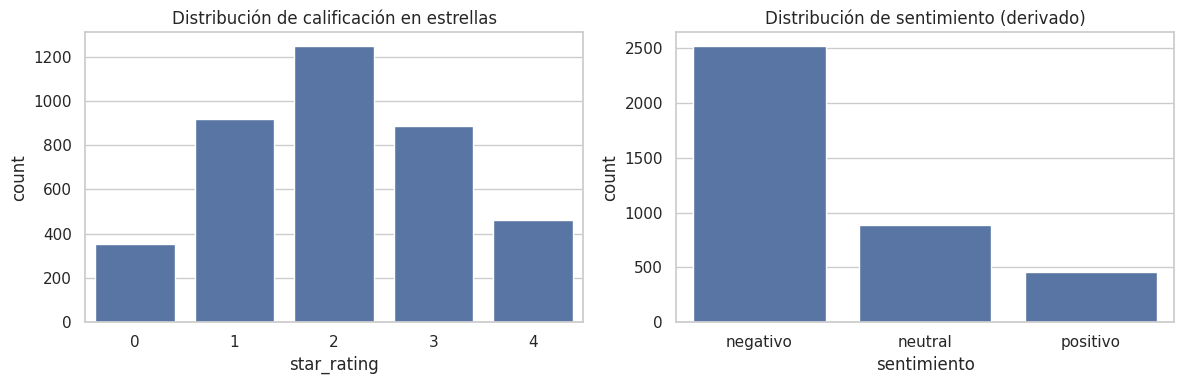

,proportion
sentimiento,
negativo,0.651
neutral,0.230
positivo,0.119


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='star_rating', order=sorted(df['star_rating'].unique()), ax=axes[0])
axes[0].set_title('Distribución de calificación en estrellas')

sns.countplot(data=df, x='sentimiento', order=['negativo', 'neutral', 'positivo'], ax=axes[1])
axes[1].set_title('Distribución de sentimiento (derivado)')

plt.tight_layout()
plt.show()

df['sentimiento'].value_counts(normalize=True).round(3)

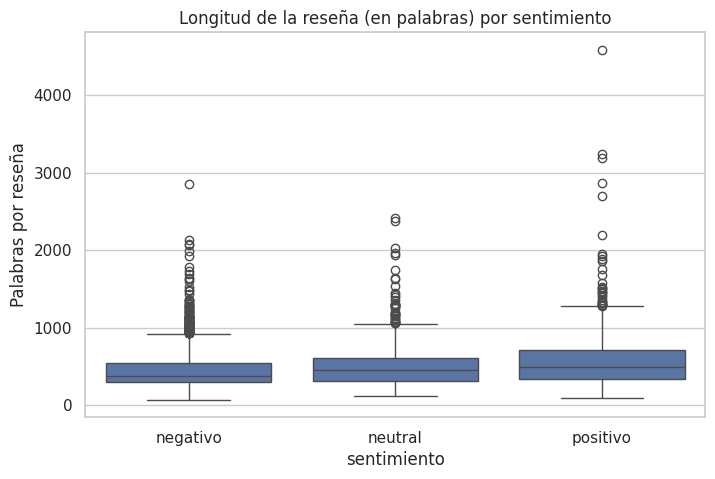

,mean,50%,min,max
sentimiento,,,,
negativo,449.879810,383.0,72.0,2859.0
neutral,506.354331,453.0,119.0,2412.0
positivo,603.659436,489.0,99.0,4585.0


In [ ]:
df['n_palabras'] = df['review_body'].str.split().apply(len)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='sentimiento', y='n_palabras', order=['negativo', 'neutral', 'positivo'])
plt.title('Longitud de la reseña (en palabras) por sentimiento')
plt.ylabel('Palabras por reseña')
plt.show()

df.groupby('sentimiento')['n_palabras'].describe()[['mean', '50%', 'min', 'max']]

In [ ]:
from spacy.lang.es.stop_words import STOP_WORDS

def simple_tokenizer(text: str):
    text = text.lower()
    text = re.sub(r'[^a-záéíóúüñ]+', ' ', text)
    return [tok for tok in text.strip().split() if tok not in STOP_WORDS and len(tok) > 2]

def top_words(texts, n=15):
    counter = Counter()
    for t in texts:
        counter.update(simple_tokenizer(t))
    return counter.most_common(n)

for sent in ['negativo', 'neutral', 'positivo']:
    subset = df.loc[df['sentimiento'] == sent, 'review_body']
    print(f'Top palabras en reseñas {sent}:')
    print(top_words(subset))
    print()

Top palabras en reseñas negativo:
[('película', 7020), ('cine', 2880), ('historia', 2594), ('personajes', 1596), ('películas', 1399), ('director', 1355), ('film', 1300), ('guión', 1299), ('vida', 1273), ('cinta', 1244), ('personaje', 1228), ('años', 1068), ('espectador', 1016), ('mundo', 1011), ('momento', 905)]

Top palabras en reseñas neutral:
[('película', 2698), ('cine', 1226), ('historia', 1071), ('vida', 676), ('film', 673), ('personajes', 631), ('director', 614), ('películas', 561), ('mundo', 529), ('años', 481), ('personaje', 473), ('guión', 449), ('espectador', 419), ('forma', 408), ('momento', 403)]

Top palabras en reseñas positivo:
[('película', 1502), ('cine', 879), ('historia', 622), ('vida', 507), ('film', 505), ('director', 438), ('mundo', 356), ('personajes', 350), ('películas', 322), ('obra', 320), ('años', 314), ('guión', 286), ('escena', 271), ('personaje', 264), ('forma', 258)]



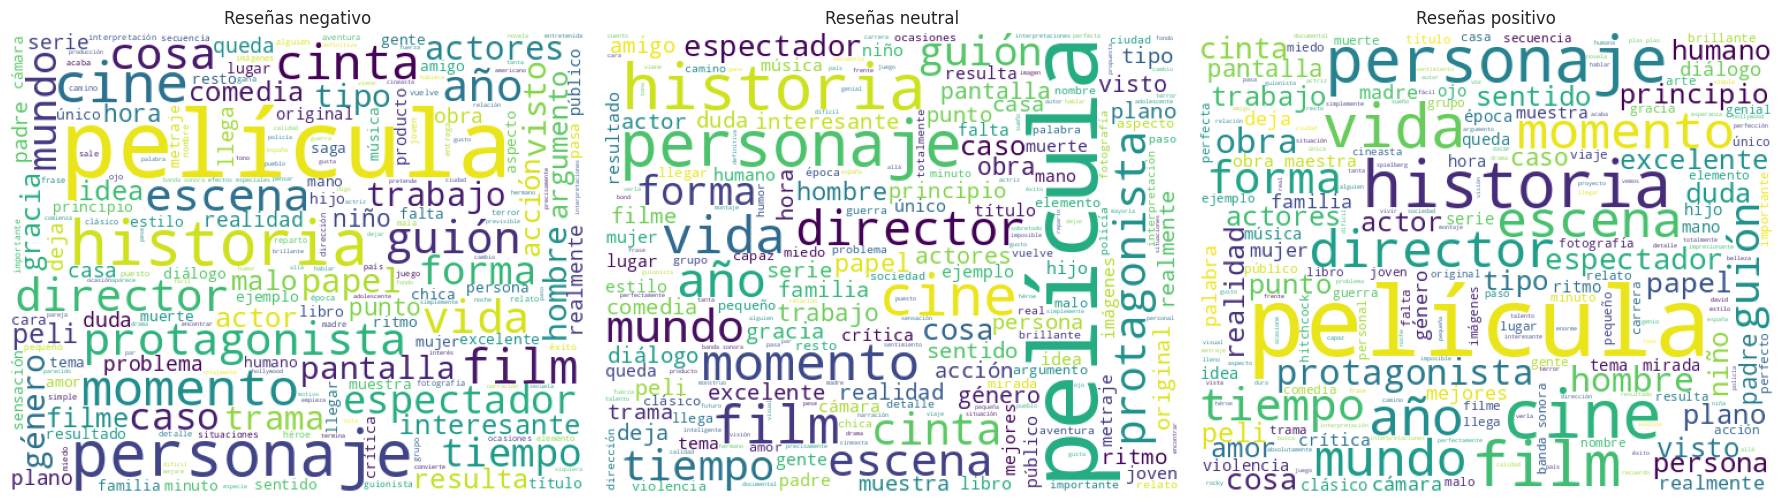

In [ ]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, sent in zip(axes, ['negativo', 'neutral', 'positivo']):
    tokens = []
    for t in df.loc[df['sentimiento'] == sent, 'review_body']:
        tokens.extend(simple_tokenizer(t))
    wc = WordCloud(width=500, height=400, background_color='white').generate(' '.join(tokens))
    ax.imshow(wc)
    ax.set_title(f'Reseñas {sent}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
for sent in ['negativo', 'neutral', 'positivo']:
    ejemplo = df.loc[df['sentimiento'] == sent, 'review_body'].sample(1, random_state=SEED).iloc[0]
    print(f'--- Ejemplo {sent} ---')
    print(ejemplo[:400], '...\n')

--- Ejemplo negativo ---
Con el tiempo Pedro Almodóvar se ha convertido en un icono y figura mediática de la industria española sobre el que se han dicho y escrito tal vez demasiadas cosas, algarabía comprensible teniendo en cuenta los posicionamientos ideológicos y el bombardeo constante a cuento de los premios, las galas, los homenajes, bla bla bla bla. Desde un cierto sector intelectual -muy encallado en la red interna ...

--- Ejemplo neutral ---
Paul Weitz (American Pie) continúa su proceso de maduración con American Dreamz, un valiente zarpazo a la imagen de George Bush ("me hice político para poder demostrar a mi padre que cualquier idiota podía hacerlo"); a la actitud de cierta prensa; a la sociedad capaz de cualquier estupidez con tal de conseguir la fama, y a los programas que ofrecen esta efímera posibilidad a cambio de extraer de l ...

--- Ejemplo positivo ---
Justa Ganadora del premio a la Mejor Película en los Premios del Cine Europeo pero injusta ganadora (a mi parecer)

### Análisis del EDA

Las clases no están balanceadas: negativo 65.1% (2.522 reseñas), neutral 23.0% (889) y positivo apenas 11.9% (461), sobre un total de 3.872. Casi dos de cada tres reseñas en muchocine.net son negativas, lo cual tiene sentido tratándose de un sitio de crítica de cine hecho por aficionados, que suelen ser más exigentes que el público general. Por este desbalance decidimos usar pesos de clase en el entrenamiento: sin ellos un modelo puede llegar a 65% de accuracy con solo predecir "negativo" siempre, sin haber aprendido nada real sobre sentimiento.

En cuanto a calidad de los datos, encontramos 3 reseñas con texto exactamente duplicado (no las quitamos, es un número insignificante) y 1 reseña completamente vacía, que sí eliminamos, quedando 3.871 reseñas en total. Esa misma reseña vacía terminó siendo relevante más adelante: es el tipo de caso que puede dejar en ceros toda la máscara de atención del modelo BiLSTM, algo que tuvimos que corregir durante las pruebas (se explica en la sección 5).

También miramos la longitud de las reseñas por clase y encontramos algo que no esperábamos: las reseñas positivas son, en promedio, las más largas (media de 604 palabras, mediana 489), seguidas de las neutrales (media 506, mediana 453) y por último las negativas (media 450, mediana 383). Es decir que cuando a alguien le encanta una película tiende a escribir más que cuando la detesta, posiblemente porque justificar el entusiasmo requiere más desarrollo que un rechazo directo.

El hallazgo que más nos sirvió para justificar el enfoque del taller fue el de las palabras más frecuentes por clase. Quitando stopwords, el top 15 de palabras es prácticamente el mismo en las tres clases: película, cine, historia, personajes, películas, director, film, guión, vida, cinta, personaje, años, espectador, mundo, momento. Es vocabulario temático de cine, no vocabulario de sentimiento. A diferencia del notebook guía, donde el tema de una noticia casi se adivina con dos o tres palabras clave, acá el "de qué habla" la reseña no dice nada sobre si es positiva o negativa. Esto confirma la idea de la introducción: el modelo no puede apoyarse en el léxico superficial y tiene que captar matices que no aparecen entre las palabras más comunes.


## 3. Preprocesamiento y tokenización

Primero hicimos el split en train, validación y prueba, y después construimos el vocabulario del tokenizador usando solo el conjunto de entrenamiento. Esto es distinto a lo que hacen los notebooks guía, donde el vocabulario se construye con el dataset completo antes de separar los conjuntos. Eso es una fuga leve de información, porque el vocabulario termina "conociendo" palabras que solo aparecen en validación o prueba, y por eso preferimos evitarlo.

In [ ]:
label2id = {'negativo': 0, 'neutral': 1, 'positivo': 2}
id2label = {v: k for k, v in label2id.items()}
df['label'] = df['sentimiento'].map(label2id)

train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
train_df['sentimiento'].value_counts(normalize=True).round(3)

Train: 2709 | Val: 581 | Test: 581


,proportion
sentimiento,
negativo,0.651
neutral,0.230
positivo,0.119


In [ ]:
MIN_FREQ = 2  # descartamos hapax legomena (palabras que aparecen una sola vez en train):
              # suelen ser nombres propios o erratas, y solo agrandan el vocabulario sin aportar señal.

def simple_tokenizer_full(text: str):
    text = text.lower()
    text = re.sub(r'[^a-záéíóúüñ0-9]+', ' ', text)
    return text.strip().split()

token_counts = Counter()
for text in train_df['review_body']:
    token_counts.update(simple_tokenizer_full(text))

vocab = {'[PAD]': 0, '[UNK]': 1}
for token, freq in token_counts.most_common():
    if freq < MIN_FREQ:
        break  # most_common ya viene ordenado de mayor a menor frecuencia
    vocab[token] = len(vocab)

print(f'Vocabulario: {len(vocab)} tokens (construido solo con el conjunto de entrenamiento)')

SEQ_LEN = 200

def tokenize_text(text: str, max_length: int = SEQ_LEN):
    tokens = simple_tokenizer_full(text)
    ids = [vocab.get(tok, vocab['[UNK]']) for tok in tokens[:max_length]]
    ids += [vocab['[PAD]']] * (max_length - len(ids))
    return ids

Vocabulario: 32717 tokens (construido solo con el conjunto de entrenamiento)


In [ ]:
class ReviewsDataset(Dataset):
    def __init__(self, dataframe, tokenizer, seq_length=SEQ_LEN):
        self.texts = dataframe['review_body'].tolist()
        self.labels = dataframe['label'].tolist()
        self.tokenizer = tokenizer
        self.seq_length = seq_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = self.tokenizer(self.texts[idx], max_length=self.seq_length)
        return {
            'input_ids': torch.tensor(ids, dtype=torch.long),
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
        }

BATCH_SIZE = 32
train_ds = ReviewsDataset(train_df, tokenize_text)
val_ds = ReviewsDataset(val_df, tokenize_text)
test_ds = ReviewsDataset(test_df, tokenize_text)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

print(f'Batches -> train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}')

Batches -> train: 85 | val: 19 | test: 19


In [ ]:
# Pesos de clase para compensar el desbalance detectado en el EDA.
class_weights_np = compute_class_weight(class_weight='balanced', classes=np.array([0, 1, 2]), y=train_df['label'])
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)
print('Pesos de clase (negativo, neutral, positivo):', class_weights_np.round(3))

Pesos de clase (negativo, neutral, positivo): [0.512 1.452 2.796]


## 4. Modelo clásico A — LSTM simple (referencia)

Este es esencialmente el mismo modelo del notebook guía: embeddings entrenables desde cero + una capa LSTM + una capa lineal, usando solo el último estado oculto. Lo entrenamos como punto de referencia antes de introducir mejoras.

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, num_classes, embedding_dim=128, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)
        _, (hidden, _) = self.lstm(embedded)
        return self.classifier(hidden[-1])

## 5. Modelo clásico B: BiLSTM con atención (la mejora que propusimos)

En vez de quedarnos solo con el último estado oculto de la LSTM, que obliga a comprimir toda la reseña en un único vector y termina olvidando parte de lo que vino antes, agregamos dos cosas. Primero, bidireccionalidad: la LSTM procesa la secuencia de izquierda a derecha y de derecha a izquierda, así que cada posición tiene en cuenta tanto el contexto anterior como el posterior. Segundo, un mecanismo de atención aditiva (estilo Bahdanau): en vez de usar solo el último estado, se calcula un promedio ponderado de todos los estados ocultos, donde el modelo aprende qué palabras merecen más peso para decidir el sentimiento, sin importar en qué posición de la reseña aparezcan.

Esto también nos da algo de interpretabilidad, porque podemos visualizar los pesos de atención y ver en qué palabras se fijó el modelo.

In [ ]:
class AdditiveAttention(nn.Module):
    '''Atención aditiva (Bahdanau) para hacer pooling ponderado sobre los
    estados ocultos de la LSTM, en lugar de usar solo el último estado.'''

    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, hidden_dim)
        self.context = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, lstm_outputs, mask):
        # lstm_outputs: (batch, seq_len, hidden_dim) | mask: (batch, seq_len)
        scores = self.context(torch.tanh(self.attn(lstm_outputs))).squeeze(-1)
        # Usamos un número negativo muy grande (no -inf) para "apagar" las
        # posiciones de padding. Si usáramos -inf y una reseña quedara con
        # CERO tokens válidos (fila de mask totalmente en 0, p. ej. una
        # reseña vacía o solo símbolos), softmax tendría que restar -inf de
        # -inf, lo que da NaN y arruina el entrenamiento desde ese batch en
        # adelante. Con un número finito, ese caso patológico simplemente
        # produce una atención uniforme en vez de NaN.
        scores = scores.masked_fill(mask == 0, -1e9)
        weights = F.softmax(scores, dim=1).unsqueeze(-1)
        weighted_sum = (lstm_outputs * weights).sum(dim=1)
        return weighted_sum, weights.squeeze(-1)


class BiLSTMAttentionClassifier(nn.Module):
    def __init__(self, vocab_size, num_classes, embedding_dim=128, hidden_dim=128, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.attention = AdditiveAttention(hidden_dim * 2)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, input_ids, return_attention=False):
        mask = (input_ids != 0).long()
        embedded = self.embedding(input_ids)
        lstm_out, _ = self.lstm(embedded)
        pooled, attn_weights = self.attention(lstm_out, mask)
        logits = self.classifier(pooled)
        if return_attention:
            return logits, attn_weights
        return logits

### 5.1 Entrenamiento de ambos modelos clásicos

Usamos el mismo ciclo de entrenamiento explícito para los dos modelos, con *early stopping* sobre la pérdida de validación (igual en espíritu al EarlyStopping de PyTorch Lightning del notebook guía).

In [ ]:
def train_model(model, train_loader, val_loader, epochs=12, lr=1e-3, weights=None, patience=3):
    model.to(device)
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []
    best_val_loss = float('inf')
    # Guardamos el estado inicial como respaldo: así, aunque ninguna época
    # llegue a mejorar val_loss (por ejemplo si algo se descarrila), siempre
    # tenemos un state_dict válido que cargar al final en vez de un None.
    best_state = {k: v.clone() for k, v in model.state_dict().items()}
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, n_train = 0.0, 0, 0
        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            logits = model(input_ids)
            loss = criterion(logits, labels)
            loss.backward()
            # Clip de gradiente: práctica estándar en RNNs para evitar que
            # gradientes muy grandes ("exploding gradients") desestabilicen
            # el entrenamiento, sobre todo en las primeras épocas.
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            train_loss += loss.item() * labels.size(0)
            train_correct += (logits.argmax(1) == labels).sum().item()
            n_train += labels.size(0)

        model.eval()
        val_loss, val_correct, n_val = 0.0, 0, 0
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                labels = batch['label'].to(device)
                logits = model(input_ids)
                loss = criterion(logits, labels)
                val_loss += loss.item() * labels.size(0)
                val_correct += (logits.argmax(1) == labels).sum().item()
                n_val += labels.size(0)

        train_loss /= n_train
        val_loss /= n_val
        history.append({
            'epoch': epoch + 1,
            'train_loss': train_loss, 'train_acc': train_correct / n_train,
            'val_loss': val_loss, 'val_acc': val_correct / n_val,
        })
        print(f"Epoch {epoch + 1}/{epochs} | train_loss={train_loss:.4f} train_acc={train_correct / n_train:.4f} "
              f"| val_loss={val_loss:.4f} val_acc={val_correct / n_val:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping en la época {epoch + 1}')
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


def plot_history(history_df, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df['epoch'], history_df['train_loss'], label='train')
    axes[0].plot(history_df['epoch'], history_df['val_loss'], label='val')
    axes[0].set_title(f'{title} — Loss'); axes[0].set_xlabel('Época'); axes[0].legend()
    axes[1].plot(history_df['epoch'], history_df['train_acc'], label='train')
    axes[1].plot(history_df['epoch'], history_df['val_acc'], label='val')
    axes[1].set_title(f'{title} — Accuracy'); axes[1].set_xlabel('Época'); axes[1].legend()
    plt.tight_layout()
    plt.show()

Epoch 1/12 | train_loss=1.1049 train_acc=0.3961 | val_loss=1.0995 val_acc=0.4251
Epoch 2/12 | train_loss=1.0436 train_acc=0.4943 | val_loss=1.1093 val_acc=0.3941
Epoch 3/12 | train_loss=0.9285 train_acc=0.5482 | val_loss=1.1755 val_acc=0.4320
Epoch 4/12 | train_loss=0.6942 train_acc=0.6781 | val_loss=1.2857 val_acc=0.4578
Early stopping en la época 4


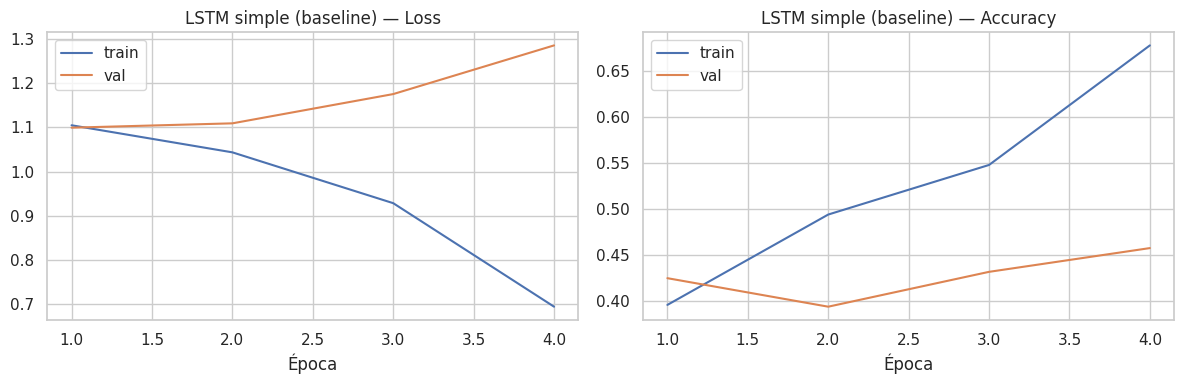

In [ ]:
lstm_model = LSTMClassifier(vocab_size=len(vocab), num_classes=3)
lstm_model, lstm_history = train_model(lstm_model, train_loader, val_loader, weights=class_weights)
plot_history(lstm_history, 'LSTM simple (baseline)')

Epoch 1/12 | train_loss=1.1005 train_acc=0.3872 | val_loss=1.0953 val_acc=0.6368
Epoch 2/12 | train_loss=1.0875 train_acc=0.4563 | val_loss=1.0801 val_acc=0.4940
Epoch 3/12 | train_loss=0.9742 train_acc=0.5633 | val_loss=1.1201 val_acc=0.4819
Epoch 4/12 | train_loss=0.7241 train_acc=0.6781 | val_loss=1.3320 val_acc=0.5714
Epoch 5/12 | train_loss=0.4728 train_acc=0.7660 | val_loss=1.5624 val_acc=0.5301
Early stopping en la época 5


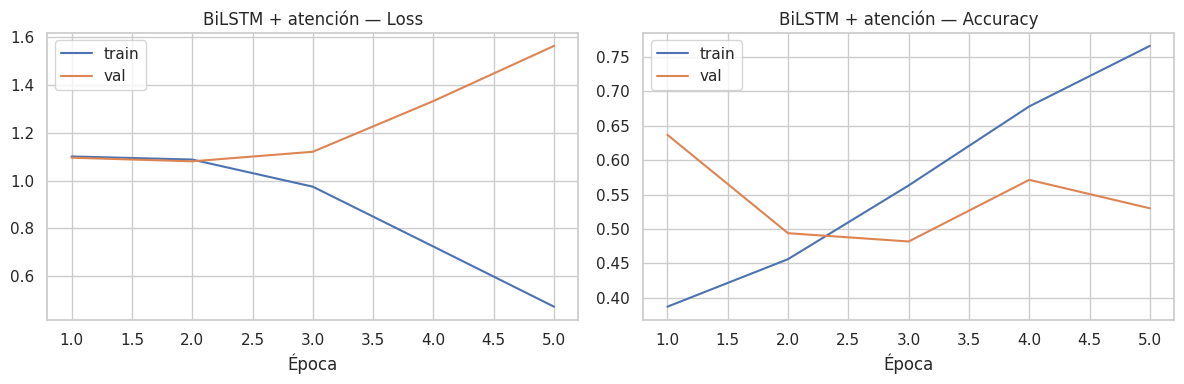

In [ ]:
bilstm_attn_model = BiLSTMAttentionClassifier(vocab_size=len(vocab), num_classes=3)
bilstm_attn_model, bilstm_attn_history = train_model(bilstm_attn_model, train_loader, val_loader, weights=class_weights)
plot_history(bilstm_attn_history, 'BiLSTM + atención')

### 5.2 Evaluación de los modelos clásicos

In [ ]:
def evaluate_classic(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            labels = batch['label']
            logits = model(input_ids)
            all_preds.extend(logits.argmax(1).cpu().tolist())
            all_labels.extend(labels.tolist())
    return np.array(all_labels), np.array(all_preds)


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['negativo', 'neutral', 'positivo'],
                yticklabels=['negativo', 'neutral', 'positivo'])
    plt.title(title); plt.ylabel('Real'); plt.xlabel('Predicho')
    plt.show()

=== LSTM simple ===
              precision    recall  f1-score   support

    negativo       0.67      0.55      0.60       379
     neutral       0.28      0.33      0.30       133
    positivo       0.09      0.14      0.11        69

    accuracy                           0.45       581
   macro avg       0.35      0.34      0.34       581
weighted avg       0.51      0.45      0.48       581



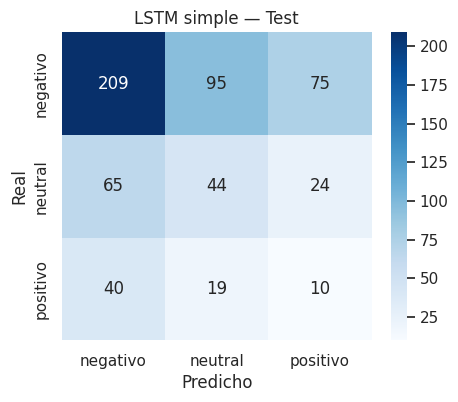

In [ ]:
y_true, y_pred_lstm = evaluate_classic(lstm_model, test_loader)
print('=== LSTM simple ===')
print(classification_report(y_true, y_pred_lstm, target_names=['negativo', 'neutral', 'positivo']))
plot_confusion(y_true, y_pred_lstm, 'LSTM simple — Test')

=== BiLSTM + atención ===
              precision    recall  f1-score   support

    negativo       0.75      0.59      0.66       379
     neutral       0.24      0.07      0.11       133
    positivo       0.19      0.68      0.30        69

    accuracy                           0.48       581
   macro avg       0.39      0.45      0.35       581
weighted avg       0.57      0.48      0.49       581



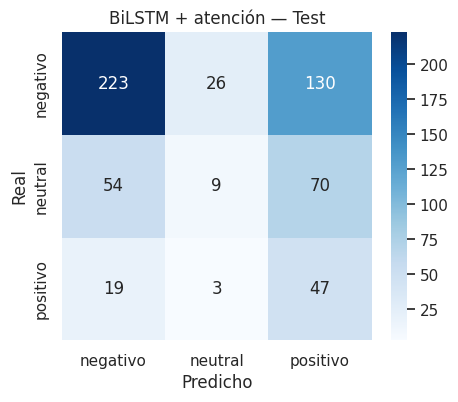

In [ ]:
y_true, y_pred_attn = evaluate_classic(bilstm_attn_model, test_loader)
print('=== BiLSTM + atención ===')
print(classification_report(y_true, y_pred_attn, target_names=['negativo', 'neutral', 'positivo']))
plot_confusion(y_true, y_pred_attn, 'BiLSTM + atención — Test')

### 5.3 Visualizando la atención

Podemos ver en qué palabras se fija el modelo para hacer su predicción probando con el siguiente simulador.

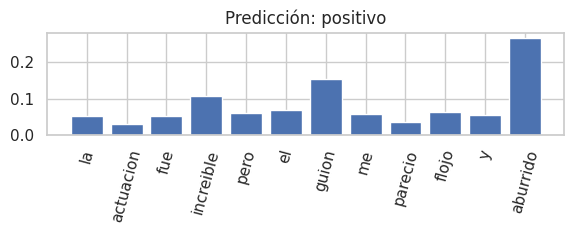

In [ ]:
def show_attention(model, text, max_length=SEQ_LEN):
    model.eval()
    tokens = simple_tokenizer_full(text)[:max_length]
    ids = tokenize_text(text, max_length=max_length)
    input_ids = torch.tensor([ids], dtype=torch.long).to(device)
    with torch.no_grad():
        logits, attn_weights = model(input_ids, return_attention=True)
    pred = id2label[logits.argmax(1).item()]
    weights = attn_weights[0][:len(tokens)].cpu().numpy()

    plt.figure(figsize=(max(6, len(tokens) * 0.4), 2.5))
    plt.bar(range(len(tokens)), weights)
    plt.xticks(range(len(tokens)), tokens, rotation=75)
    plt.title(f'Predicción: {pred}')
    plt.tight_layout()
    plt.show()

show_attention(bilstm_attn_model, 'la actuacion fue increible pero el guion me parecio flojo y aburrido')

### Comparación entre el LSTM simple y el BiLSTM con atención

El F1 macro subió de 0.339 (LSTM simple) a 0.354 (BiLSTM con atención), y la accuracy pasó de 0.453 a 0.480. La mejora en el promedio es pequeña, pero lo interesante aparece cuando se mira el recall por clase. En la clase negativo el LSTM tenía 0.55 y el BiLSTM 0.59, una mejora leve. En neutral el LSTM tenía 0.33 y el BiLSTM cayó a apenas 0.07. En positivo el LSTM tenía solo 0.14 y el BiLSTM subió a 0.68.

En otras palabras, el BiLSTM con atención resuelve casi por completo el punto ciego que tenía el LSTM con la clase positivo, pero lo hace prácticamente abandonando la clase neutral. Revisando la matriz de confusión, el modelo pasó a predecir "positivo" con mucha más frecuencia en general, incluyendo 130 reseñas que en realidad eran negativas. Creemos que esto tiene que ver con el peso de clase que le dimos a "positivo" (2.796, el más alto de los tres), que empuja fuerte al modelo hacia esa clase durante el entrenamiento.

La clase neutral fue, con diferencia, la más difícil para los dos modelos. Tiene sentido: una reseña de 3 estrellas suele mezclar elogios y críticas, y es mucho más ambigua de separar que un extremo claro.

En las curvas de entrenamiento se ve el mismo patrón en ambos modelos: el train loss baja de forma sostenida mientras el val loss toca fondo temprano (época 1 en el LSTM simple, época 2 en el BiLSTM) y después empieza a subir, lo que activa el early stopping en la época 4 y 5 respectivamente. Con unas 2.700 reseñas de entrenamiento, ambos modelos terminan memorizando antes de poder generalizar mucho más.

También probamos la visualización de atención con la frase "la actuación fue increíble pero el guion me pareció flojo y aburrido", que mezcla un elogio con una crítica. El gráfico le da el peso más alto a "aburrido" y bastante peso también a "guion", es decir que el modelo sí se fija en las palabras cargadas de sentimiento negativo. Sin embargo la predicción final fue "positivo". Esto nos pareció una buena lección sobre interpretabilidad: la atención muestra en qué se fijó el modelo, pero no explica por qué decidió lo que decidió, porque la capa clasificadora que viene después puede llegar a una conclusión distinta a la que uno esperaría solo mirando los pesos de atención, sobre todo si esa capa está sesgada por los pesos de clase hacia "positivo".


## 6. Modelo moderno: Transformer preentrenado en español (BETO)

Hasta este punto nuestros embeddings se entrenaron desde cero, usando únicamente las cerca de 2.700 reseñas de entrenamiento. Un modelo preentrenado como BETO (un BERT entrenado desde cero con un corpus grande en español, por la Universidad de Chile) ya trae conocimiento del idioma aprendido de una cantidad de texto mucho mayor, y genera representaciones contextuales, es decir que el vector de una palabra cambia según la oración en la que aparece, a diferencia de nuestro embedding fijo por palabra.

En esta sección hicimos fine-tuning de BETO sobre el mismo problema y el mismo conjunto de datos, para poder compararlo contra los modelos clásicos. Con GPU usaríamos el mismo max_length nominal (200) que en los modelos clásicos, aunque BETO tokeniza por subpalabras mientras que nuestro tokenizador clásico tokeniza por palabras completas, así que 200 tokens no equivale exactamente a la misma cantidad de texto en ambos casos.

No tuvimos GPU disponible, y hacer fine-tuning completo de BERT en CPU es demasiado lento (podía tardar varias horas). Por eso el código detecta automáticamente si no hay GPU y activa un modo reducido: menos épocas, secuencias más cortas, una muestra del conjunto de entrenamiento y casi toda la red congelada salvo las últimas dos capas y el clasificador. Esto hace que la comparación contra los modelos clásicos deje de ser perfectamente justa, y lo tuvimos en cuenta al interpretar los resultados.

In [ ]:
from datasets import Dataset as HFDataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
import evaluate as hf_evaluate

MODEL_NAME = 'dccuchile/bert-base-spanish-wwm-cased'
bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Modo rápido automático si no hay GPU: menos épocas, secuencias más cortas
# y una muestra del set de entrenamiento/validación (el set de prueba se deja
# completo para que la comparación final siga siendo justa).
CPU_FALLBACK = device.type != 'cuda'
if CPU_FALLBACK:
    print('No se detectó GPU: activando modo rápido para BETO (ideal: cambia a GPU en '
          'Entorno de ejecución -> Cambiar tipo de entorno de ejecución).')

BERT_SEQ_LEN = 96 if CPU_FALLBACK else SEQ_LEN
BERT_EPOCHS = 2 if CPU_FALLBACK else 6
bert_train_df = train_df.sample(n=min(1500, len(train_df)), random_state=SEED) if CPU_FALLBACK else train_df
bert_val_df = val_df.sample(n=min(300, len(val_df)), random_state=SEED) if CPU_FALLBACK else val_df

def tokenize_batch(examples):
    return bert_tokenizer(examples['review_body'], truncation=True, padding='max_length', max_length=BERT_SEQ_LEN)

def to_hf_dataset(dataframe):
    d = dataframe[['review_body', 'label']].reset_index(drop=True).rename(columns={'label': 'labels'})
    return HFDataset.from_pandas(d)

train_hf = to_hf_dataset(bert_train_df).map(tokenize_batch, batched=True)
val_hf = to_hf_dataset(bert_val_df).map(tokenize_batch, batched=True)
test_hf = to_hf_dataset(test_df).map(tokenize_batch, batched=True)

columns = ['input_ids', 'attention_mask', 'labels']
train_hf.set_format(type='torch', columns=columns)
val_hf.set_format(type='torch', columns=columns)
test_hf.set_format(type='torch', columns=columns)

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/480k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

No se detectó GPU: activando modo rápido para BETO (ideal: cambia a GPU en Entorno de ejecución -> Cambiar tipo de entorno de ejecución).


Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/581 [00:00<?, ? examples/s]

In [ ]:
bert_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3).to(device)

if CPU_FALLBACK:
    # Congelamos casi todo BERT y solo entrenamos las últimas 2 capas del
    # encoder + la cabeza de clasificación: en CPU, esto reduce bastante el
    # costo del entrenamiento (menos gradientes que calcular), a cambio de
    # perder algo de desempeño frente a un fine-tuning completo.
    for param in bert_model.base_model.parameters():
        param.requires_grad = False
    for layer in bert_model.base_model.encoder.layer[-2:]:
        for param in layer.parameters():
            param.requires_grad = True

accuracy_metric = hf_evaluate.load('accuracy')
f1_metric = hf_evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_metric.compute(predictions=preds, references=labels)['accuracy'],
        'f1_macro': f1_metric.compute(predictions=preds, references=labels, average='macro')['f1'],
    }


class WeightedTrainer(Trainer):
    '''Trainer que usa los mismos pesos de clase que los modelos clásicos,
    para que el desbalance se maneje igual en los tres modelos.'''

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  440MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

In [ ]:
training_args = TrainingArguments(
    output_dir='./beto-sentiment',
    num_train_epochs=BERT_EPOCHS,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_steps=20,
    report_to='none',
    seed=SEED,
)

trainer = WeightedTrainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=val_hf,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.091224,1.091494,0.503333,0.371315
2,1.074067,1.085775,0.513333,0.414057


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=188, training_loss=1.0896572255073709, metrics={'train_runtime': 1098.2796, 'train_samples_per_second': 2.732, 'train_steps_per_second': 0.171, 'total_flos': 148001297472000.0, 'train_loss': 1.0896572255073709, 'epoch': 2.0})

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
1.074067,1.082935,2,0.483649,0.375635


{'eval_loss': 1.082934856414795, 'eval_accuracy': 0.4836488812392427, 'eval_f1_macro': 0.3756350051242468}


              precision    recall  f1-score   support

    negativo       0.68      0.60      0.64       379
     neutral       0.23      0.24      0.24       133
    positivo       0.21      0.33      0.25        69

    accuracy                           0.48       581
   macro avg       0.37      0.39      0.38       581
weighted avg       0.52      0.48      0.50       581



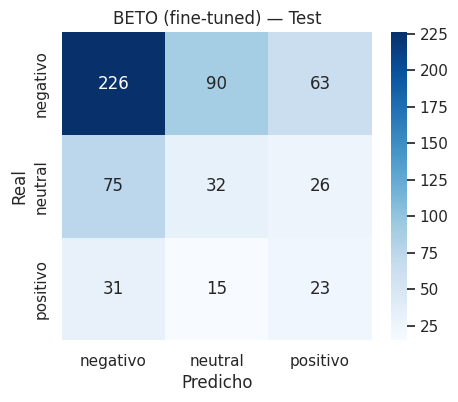

In [ ]:
test_results = trainer.evaluate(test_hf)
print(test_results)

preds_output = trainer.predict(test_hf)
y_pred_bert = np.argmax(preds_output.predictions, axis=1)
y_true_bert = preds_output.label_ids

print(classification_report(y_true_bert, y_pred_bert, target_names=['negativo', 'neutral', 'positivo']))
plot_confusion(y_true_bert, y_pred_bert, 'BETO (fine-tuned) — Test')

### Análisis del modelo BETO

BETO obtuvo un F1 macro de 0.376 y una accuracy de 0.484, los mejores valores de los tres modelos (LSTM simple: 0.339 y 0.453; BiLSTM con atención: 0.354 y 0.480). La mejora sobre el BiLSTM es modesta, +0.022 en F1 macro, pero hay que verla en contexto: BETO entrenó en el modo reducido de CPU, con solo 1.500 de las 2.709 reseñas de entrenamiento que usaron los otros dos modelos, secuencias recortadas a 96 tokens en vez de 200, apenas 2 épocas, y con casi toda la red congelada. BETO ya tiene una noción del idioma antes de ver una sola reseña nuestra, y eso compensa buena parte de la desventaja de datos y tiempo con la que corrió.

La matriz de confusión también nos pareció más pareja que las de los modelos clásicos. Mientras el LSTM casi no detectaba positivo y el BiLSTM casi no detectaba neutral, BETO tiene un desempeño más equilibrado entre las tres clases: recall de 0.60 en negativo, 0.24 en neutral y 0.33 en positivo. Ninguna clase colapsa por completo, aunque tampoco hay ninguna que se destaque especialmente.

Con solo 2 épocas y la mayoría de las capas congeladas, el modelo no alcanza a sobreajustar tanto como los clásicos. El eval loss terminó en 1.083, bastante cerca del loss inicial de las LSTM, lo que sugiere que apenas estaba empezando a especializarse cuando terminó el entrenamiento. Es razonable pensar que con más épocas y datos, es decir con GPU, seguiría mejorando.


## 7. Comparación final: clásico vs. moderno

Ahora comparamos los tres modelos con las mismas métricas sobre el mismo conjunto de prueba: accuracy, F1 macro (que penaliza más el desempeño pobre en la clase minoritaria) y número de parámetros entrenables.

In [ ]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

comparison = pd.DataFrame([
    {
        'modelo': 'LSTM simple',
        'accuracy': (y_pred_lstm == y_true).mean(),
        'f1_macro': f1_score(y_true, y_pred_lstm, average='macro'),
        'parametros': count_params(lstm_model),
    },
    {
        'modelo': 'BiLSTM + atención',
        'accuracy': (y_pred_attn == y_true).mean(),
        'f1_macro': f1_score(y_true, y_pred_attn, average='macro'),
        'parametros': count_params(bilstm_attn_model),
    },
    {
        'modelo': 'BETO (fine-tuned)',
        'accuracy': test_results['eval_accuracy'],
        'f1_macro': test_results['eval_f1_macro'],
        'parametros': count_params(bert_model),
    },
])
comparison

,modelo,accuracy,f1_macro,parametros
0,LSTM simple,0.452668,0.339313,4320259
1,BiLSTM + atención,0.480207,0.354491,4534659
2,BETO (fine-tuned),0.483649,0.375635,109853187


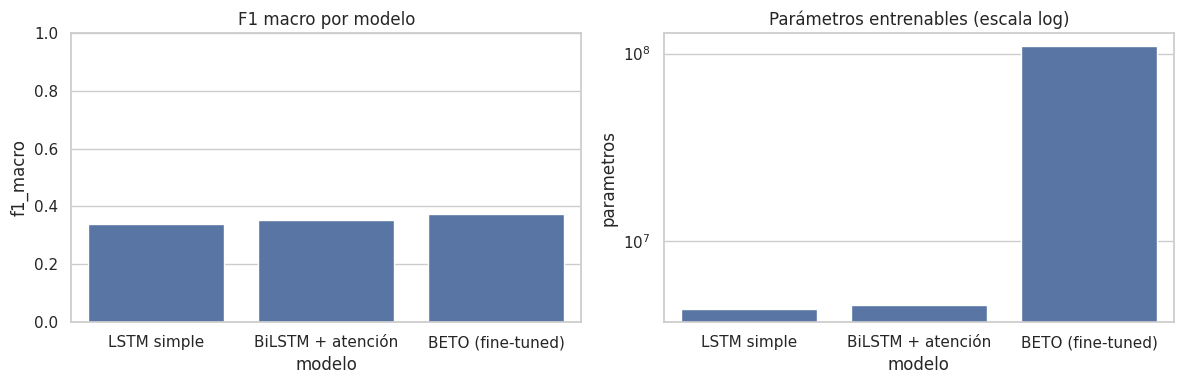

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=comparison, x='modelo', y='f1_macro', ax=axes[0])
axes[0].set_title('F1 macro por modelo')
axes[0].set_ylim(0, 1)

sns.barplot(data=comparison, x='modelo', y='parametros', ax=axes[1])
axes[1].set_title('Parámetros entrenables (escala log)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

### 7.1 Cruce de errores entre modelos

Los casos más interesantes son aquellos donde BETO acierta pero el modelo clásico falla, o al revés: nos dicen en qué tipo de reseñas realmente ayuda tener contexto o preentrenamiento.

In [ ]:
results_df = test_df.reset_index(drop=True).copy()
results_df['real'] = y_true
results_df['pred_lstm'] = y_pred_lstm
results_df['pred_attn'] = y_pred_attn
results_df['pred_bert'] = y_pred_bert

acierta_bert_falla_attn = results_df[
    (results_df['pred_bert'] == results_df['real']) & (results_df['pred_attn'] != results_df['real'])
][['review_body', 'real', 'pred_attn', 'pred_bert']]

print(f'Casos donde BETO acierta y BiLSTM+atención falla: {len(acierta_bert_falla_attn)}')
acierta_bert_falla_attn.head(10)

Casos donde BETO acierta y BiLSTM+atención falla: 126


,review_body,real,pred_attn,pred_bert
2,Vaya por delante que siempre he sentido una ex...,1,0,1
9,"De la mano de Quentin Tarantino, Eli Roth nos ...",0,2,0
14,¡Ya era hora! No había vuelto a tener noticias...,1,0,1
15,Y vuelta otra vez con el tema zombi. Primero l...,0,1,0
29,Stendhal podría ver esta película tranquilamen...,0,2,0
46,Creo que a Zemeckis se le ha pirado la pinza. ...,0,2,0
48,"Dentro del cine de entretenimiento clásico, la...",0,2,0
50,Partiendo de que no he visto la película origi...,0,2,0
51,"Veo del tirón y sin ningún motivo Motel Hell, ...",0,2,0
58,El cineasta Robert Rodríguez tomó como story b...,0,2,0


In [ ]:
falla_bert_acierta_attn = results_df[
    (results_df['pred_bert'] != results_df['real']) & (results_df['pred_attn'] == results_df['real'])
][['review_body', 'real', 'pred_attn', 'pred_bert']]

print(f'Casos donde BiLSTM+atención acierta y BETO falla: {len(falla_bert_acierta_attn)}')
falla_bert_acierta_attn.head(10)

Casos donde BiLSTM+atención acierta y BETO falla: 124


,review_body,real,pred_attn,pred_bert
0,"La cartelera es como una caja de bombones, sie...",2,2,0
6,Elprimerhombre recuerda a los hermanos Marx (G...,2,2,0
17,Si bien la cinta de Rodriguez es excelente y p...,0,0,1
19,Me molesta mucho cuando un creador (llámese di...,0,0,1
20,"El cine indie cada vez está mejorando más, cos...",2,2,1
22,Si no fuera por Kirsten Dunst (adorable hasta ...,0,0,2
27,"No he lído el libro, empezando por ahí. Por es...",0,0,1
31,Así se estropea una licencia cojonuda rodando ...,0,0,1
42,"Después de ""Cars"", el mundo del cine debía hab...",0,0,2
47,"Aunque sólo sea para una minoría, La Maldición...",2,2,0


### Análisis comparativo final

En F1 macro el orden terminó siendo BETO (0.376), luego BiLSTM con atención (0.354) y por último LSTM simple (0.339). La jerarquía que esperábamos se cumplió, pero las diferencias entre los tres son pequeñas (todos entre 0.34 y 0.38) frente a una diferencia enorme en costo: BETO tiene 109.8 millones de parámetros contra 4.3 y 4.5 millones de los modelos clásicos, unas 24 veces más, y tardó cerca de 18 minutos en CPU en modo reducido frente a segundos de los otros dos. Para este dataset esa relación costo beneficio es difícil de justificar tal cual, sobre todo considerando que BETO corrió en desventaja. Con un fine-tuning completo en GPU es probable que la diferencia fuera mayor y sí alcanzara a justificar el costo.

Revisamos los 126 casos donde BETO acierta y el BiLSTM con atención falla, y varios de ellos son reseñas realmente negativas donde el BiLSTM predijo positivo y BETO acertó con negativo. Es el mismo patrón que ya habíamos visto en la matriz de confusión del BiLSTM, esa tendencia a predecir positivo de más. En los 124 casos donde ocurre lo contrario no encontramos un patrón tan claro: el BiLSTM acierta tanto en negativas como en positivas donde BETO se equivoca en direcciones distintas. Esto es consistente con que BETO entrenó con menos datos y menos épocas en este modo reducido, probablemente sin terminar de estabilizar sus propias fronteras de decisión.

El demo con frases escritas por nosotros fue lo más revelador. Con "un desastre de principio a fin, actuaciones planas y guion predecible", una reseña negativa sin ambigüedad y sin negaciones, el LSTM y BETO acertaron con negativo, pero el BiLSTM con atención predijo positivo. Es un fallo claro en un caso que no debería ser difícil, y confirma en vivo el sesgo hacia "positivo" que ya habíamos visto en las métricas agregadas. En cambio, con frases como "no la odié, pero tampoco me pareció memorable" y "esperaba mucho más... pero no fue tan mala como decían", que tienen doble negación y son genuinamente difíciles, tanto el BiLSTM como BETO se alejaron del negativo ingenuo que daría un modelo que solo mira palabras sueltas como "odié" o "mala", lo cual muestra que ambos manejan negaciones bastante mejor que el LSTM simple, aunque no siempre de forma consistente entre ellos.

Si tuviéramos que elegir un modelo para producción, depende del objetivo. Si el costo de cómputo importa y basta con distinguir negativo de no negativo, el BiLSTM con atención es razonable, siempre que se corrija su sesgo hacia positivo, por ejemplo ajustando los pesos de clase. Si lo que importa es la calidad general y hay presupuesto de cómputo, BETO con un fine-tuning completo en GPU nos parece la apuesta más sólida.

## 8. Demo interactivo

Aquí se puede probar cada uno los modelos con distintas frases.

In [ ]:
def predict_all(text):
    ids = torch.tensor([tokenize_text(text)], dtype=torch.long).to(device)

    resultados = {}
    for nombre, modelo in [('LSTM simple', lstm_model), ('BiLSTM + atención', bilstm_attn_model)]:
        modelo.eval()
        with torch.no_grad():
            logits = modelo(ids)
        resultados[nombre] = id2label[logits.argmax(1).item()]

    bert_inputs = bert_tokenizer(text, return_tensors='pt', truncation=True,
                                  padding='max_length', max_length=BERT_SEQ_LEN).to(bert_model.device)
    with torch.no_grad():
        bert_logits = bert_model(**bert_inputs).logits
    resultados['BETO'] = id2label[bert_logits.argmax(1).item()]
    return resultados


frases_de_prueba = [
    'Una obra maestra, la mejor pelicula que he visto en años',
    'No la odie, pero tampoco me parecio memorable',
    'Un desastre de principio a fin, actuaciones planas y guion predecible',
    'Esperaba mucho mas dado el elenco, pero no fue tan mala como decian',
]

for texto in frases_de_prueba:
    print(texto)
    print(predict_all(texto))
    print()

Una obra maestra, la mejor pelicula que he visto en años
{'LSTM simple': 'negativo', 'BiLSTM + atención': 'positivo', 'BETO': 'neutral'}

No la odie, pero tampoco me parecio memorable
{'LSTM simple': 'negativo', 'BiLSTM + atención': 'positivo', 'BETO': 'positivo'}

Un desastre de principio a fin, actuaciones planas y guion predecible
{'LSTM simple': 'negativo', 'BiLSTM + atención': 'positivo', 'BETO': 'negativo'}

Esperaba mucho mas dado el elenco, pero no fue tan mala como decian
{'LSTM simple': 'negativo', 'BiLSTM + atención': 'negativo', 'BETO': 'positivo'}



Además de las cuatro frases de arriba probamos varias más con negaciones, sarcasmo y opiniones mixtas. En general los tres modelos rara vez coinciden en los casos ambiguos, y el BiLSTM con atención es el que más se inclina hacia "positivo" incluso en frases con tono negativo, lo cual concuerda con lo que ya se vio en las métricas y en la matriz de confusión.

## Conclusiones

### Qué le agregamos a este taller, por qué, y si funcionó

Cambiamos el dominio de noticias a sentimiento en reseñas de cine porque nos pareció un problema más exigente: el sentimiento depende de matices y negaciones, no solo de vocabulario temático. El EDA confirmó esa idea, porque las tres clases de sentimiento comparten casi el mismo top de palabras frecuentes, todas de vocabulario cinéfilo genérico, así que el léxico superficial no alcanza y hay que modelar matices. En ese sentido sí funcionó como esperábamos.

Reformulamos el problema en tres clases a partir de las estrellas y limpiamos los datos antes de entrenar. Esto nos sirvió para detectar un desbalance fuerte (65/23/12 por ciento) y una reseña vacía que, sin la limpieza, habría producido una fila de atención completamente en blanco.

Construir el vocabulario solo con el conjunto de entrenamiento, a diferencia de los notebooks guía, es una corrección metodológica que no podemos medir directamente porque no corrimos la versión con fuga de información para comparar, pero es una práctica más correcta.

Los pesos de clase por el desbalance dieron resultados mixtos. Mejoraron el F1 macro y el recall en las clases minoritarias, pero el costo fue real: la accuracy de los tres modelos, entre 0.45 y 0.48, terminó por debajo del baseline ingenuo de predecir siempre negativo, que da 65.1%. Es el trade-off esperado entre accuracy y F1 macro cuando hay desbalance, y nos pareció mejor dejarlo explícito.

El BiLSTM con atención, en vez del LSTM de una sola dirección del notebook guía, subió el F1 macro de 0.339 a 0.354 y resolvió el punto ciego del LSTM con la clase positivo, pero a cambio casi abandonó la clase neutral y quedó con un sesgo claro a sobre predecir positivo, algo que confirmamos en vivo en el demo con una reseña negativa sin ambigüedad. La atención sí sirvió para interpretar en qué palabras se fijaba el modelo, aunque encontramos un caso donde esa evidencia no coincidió con la predicción final.

La comparación contra BETO fue la parte que más nos costó, porque no tuvimos GPU disponible. Aun así obtuvo el mejor F1 macro y la matriz de confusión más equilibrada entre las tres clases, a pesar de correr con menos datos, secuencias más cortas, menos épocas y casi toda la red congelada. El costo es 24 veces más parámetros y mucho más tiempo de entrenamiento para una mejora de apenas 0.022 en F1 macro sobre el BiLSTM, pero creemos que esa brecha crecería con un fine-tuning completo en GPU.

En resumen, sí funcionó: la jerarquía que armamos, LSTM simple, luego BiLSTM con atención, luego BETO, mejoró el F1 macro de forma consistente (0.339, 0.354, 0.376), lo cual confirma que arquitecturas más sofisticadas y representaciones preentrenadas ayudan en una tarea de sentimiento. Pero la mejora no fue pareja entre clases ni gratuita en costo computacional, y entender eso nos parece el hallazgo más importante del taller, más allá del número final de F1 macro.

## Referencias

Dataset us-lsi/muchocine, curado por el Dr. Fermín L. Cruz Mata de la Universidad de Sevilla, reseñas originales de muchocine.net.

Modelo preentrenado dccuchile/bert-base-spanish-wwm-cased (BETO), Cañete et al., Universidad de Chile.

Notebooks guía del curso: 3-embeddings-y-lstm-minimo.ipynb y 4-lstm-avanzado-con-pytorch-lightning.ipynb.

Bahdanau, D., Cho, K. y Bengio, Y. (2014). Neural Machine Translation by Jointly Learning to Align and Translate. Mecanismo de atención aditiva usado en la sección 5.
